# Which NFL positions are worth paying for?

**Question:** Over 2013–2025, does the share of a team's salary cap spent on a position predict winning, and does it matter more at some positions than others? Do starters and bench players behave differently?

**Data** (all free, via `nflreadpy`): Over the Cap per-player cap hits, PFR snap counts, game results. Built by `src/build_data.py`.

**Key definitions**
- *Cap share* = a position group's cap hits ÷ the team's total tracked cap hits that season (so it is comparable across years as the cap grows).
- *Starter* = top-N players at the position by snaps (QB1, RB1, WR3, TE1, OL5, DL2, EDGE2, LB2, CB3, S2 = 11 offense / 11 defense). Everyone else, including injured players with 0 snaps, is *bench*.
- *Success* = regular-season point differential per game (less noisy than win %); win % used as a check.

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import statsmodels.formula.api as smf
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", "{:.3f}".format)

ts = pd.read_parquet("data/team_season.parquet")
ps = pd.read_parquet("data/player_season.parquet")
POS = ["QB", "RB", "WR", "TE", "OL", "DL", "EDGE", "LB", "CB", "S"]

# work in percentage points of cap so coefficients read as "per +1 point of cap share"
for p in POS:
    ts[f"{p}_st"] = ts[f"{p}_starter_share"] * 100
    ts[f"{p}_bn"] = ts[f"{p}_bench_share"] * 100
ts["ST_pct"] = ts["ST_all_share"] * 100
ts["bench_all"] = ts[[f"{p}_bn" for p in POS]].sum(axis=1)

def fit(formula, data=None):
    # season fixed effects absorb league-wide year effects; SEs clustered by team
    data = ts if data is None else data   # look up ts at call time (it gets re-sorted/extended below)
    return smf.ols(formula + " + C(season)", data).fit(cov_type="cluster", cov_kwds={"groups": data["team"]})

print(f"{len(ts)} team-seasons, {ts.season.min()}-{ts.season.max()}, {ts.team.nunique()} teams")
ts[["tracked_cap_m", "win_pct", "pt_diff_pg"]].describe().T

416 team-seasons, 2013-2025, 32 teams


,count,mean,std,min,25%,50%,75%,max
tracked_cap_m,416.000,159.657,37.066,65.529,129.758,158.513,181.921,270.883
win_pct,416.000,0.500,0.191,0.000,0.375,0.500,0.647,0.938
pt_diff_pg,416.000,0.002,6.070,-13.375,-4.500,-0.235,4.507,15.562


## 1. Where does the money go?

OL is the biggest line item (about 19% of the cap, 13% on the five starters alone). QB, WR, EDGE, DL and CB each take 10–11%. RB and TE are the cheapest groups. QB spend is the most uneven across teams, ranging from about 1% of cap (rookie deals) to 16%+ (franchise contracts).

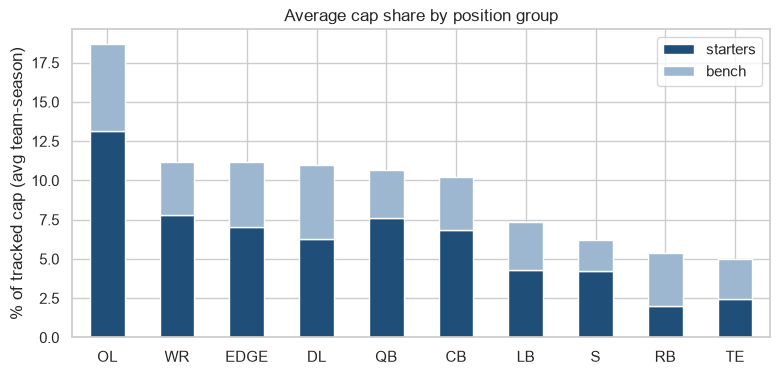

,starters,bench,total
OL,13.100,5.500,18.700
WR,7.800,3.400,11.200
EDGE,7.100,4.100,11.200
DL,6.200,4.800,11.000
QB,7.600,3.100,10.700
CB,6.900,3.400,10.200
LB,4.300,3.000,7.400
S,4.200,2.000,6.200
RB,2.000,3.400,5.400
TE,2.400,2.600,5.000


In [2]:
mix = pd.DataFrame({"starters": [ts[f"{p}_starter_share"].mean() for p in POS],
                    "bench": [ts[f"{p}_bench_share"].mean() for p in POS]}, index=POS) * 100
mix["total"] = mix.sum(axis=1)
mix = mix.sort_values("total", ascending=False)
ax = mix[["starters", "bench"]].plot.bar(stacked=True, figsize=(9, 4), color=["#1f4e79", "#9db7d1"])
ax.set(ylabel="% of tracked cap (avg team-season)", title="Average cap share by position group"); plt.xticks(rotation=0)
plt.show(); mix.round(1)

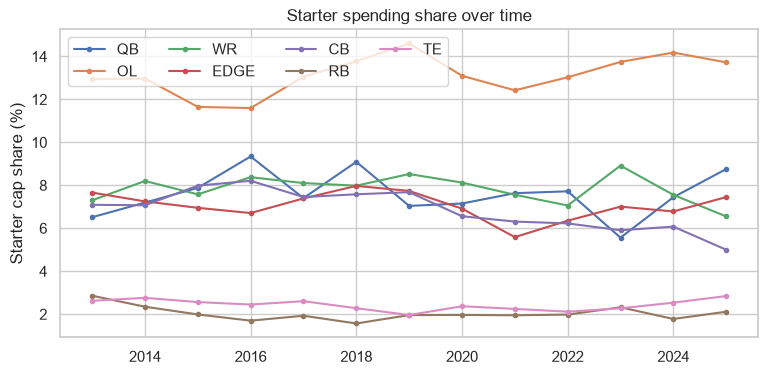

In [3]:
trend = ts.groupby("season")[[f"{p}_st" for p in POS]].mean()
fig, ax = plt.subplots(figsize=(9, 4))
for p in ["QB", "OL", "WR", "EDGE", "CB", "RB", "TE"]:
    ax.plot(trend.index, trend[f"{p}_st"], marker="o", ms=3, label=p)
ax.set(ylabel="Starter cap share (%)", title="Starter spending share over time"); ax.legend(ncol=4); plt.show()

## 2. Which positions' starters matter most? (all positions, one model)

**How to read this:** the baseline is bench/depth spending, so most coefficients are positive almost by construction (starters should beat depth). What matters is the *ranking and the uncertainty*. 1 point of cap share is roughly $1.6M for an average team.

- **QB stands out most reliably:** about +0.31 pts/game per point of cap share, and the interval is tight.
- **TE has the biggest coefficient (+0.44) but a very wide interval.** TE is only about 2% of the cap, so a few teams with elite TEs drive this. Treat it as a hint, not a finding.
- **EDGE, CB and OL** show modest, statistically significant effects (about +0.15 to +0.19).
- **S, DL, LB, RB and WR** are not distinguishable from zero.

The model explains only ~10% of the variance in point differential. Cap allocation is one small piece of what decides seasons.

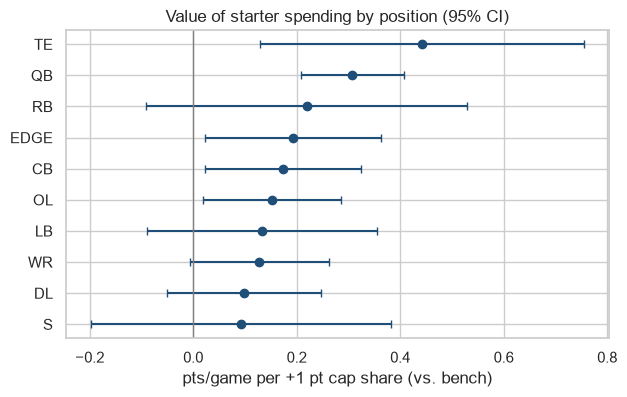

R² = 0.10, n = 416


,coef,lo,hi,p
S,0.092,-0.198,0.382,0.533
DL,0.098,-0.051,0.247,0.199
WR,0.128,-0.007,0.262,0.063
LB,0.133,-0.090,0.356,0.243
OL,0.152,0.018,0.285,0.026
CB,0.173,0.022,0.324,0.024
EDGE,0.193,0.022,0.364,0.027
RB,0.219,-0.092,0.530,0.167
QB,0.307,0.207,0.407,0.000
TE,0.442,0.129,0.755,0.006


In [4]:
# bench spending is the reference group: each coefficient = effect on point diff/game of moving
# +1 point of cap share from bench depth into that position's starters
m_joint = fit("pt_diff_pg ~ " + " + ".join(f"{p}_st" for p in POS) + " + ST_pct")
res = pd.DataFrame({"coef": m_joint.params, "lo": m_joint.conf_int()[0], "hi": m_joint.conf_int()[1],
                    "p": m_joint.pvalues}).loc[[f"{p}_st" for p in POS]]
res.index = POS; res = res.sort_values("coef")
fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(res.coef, range(len(res)), xerr=[res.coef - res.lo, res.hi - res.coef], fmt="o", color="#1f4e79", capsize=3)
ax.axvline(0, color="grey", lw=1); ax.set_yticks(range(len(res))); ax.set_yticklabels(res.index)
ax.set(xlabel="pts/game per +1 pt cap share (vs. bench)", title="Value of starter spending by position (95% CI)")
plt.show(); print(f"R² = {m_joint.rsquared:.2f}, n = {int(m_joint.nobs)}"); res.round(3)

## 3. Starters vs. bench, position by position

Putting starter and bench spending in the same model per position:

- **QB:** starter spend helps (+0.15, p=0.01) **and bench QB spend hurts** (−0.30, p<0.001). Money tied up in non-starting QBs usually means a failed or injured QB situation.
- **OL:** paying *starters* more shows nothing, but money on OL who are *not* in the top five by snaps is clearly bad (−0.33, p=0.001). That is consistent with injured or benched linemen eating cap.
- **TE:** starter spend again looks positive (+0.38), with the same small-sample caution.
- **WR, RB, DL, EDGE, LB, CB, S:** neither starter nor bench spend is distinguishable from zero here.

*Section 9 digs into the QB and OL bench results: they turn out to be mostly injured-reserve money, not wasted spending.*

In [5]:
rows = []
for p in POS:
    m = fit(f"pt_diff_pg ~ {p}_st + {p}_bn")
    rows.append({"pos": p, "starter_coef": m.params[f"{p}_st"], "starter_p": m.pvalues[f"{p}_st"],
                 "bench_coef": m.params[f"{p}_bn"], "bench_p": m.pvalues[f"{p}_bn"]})
sb = pd.DataFrame(rows).set_index("pos"); sb.round(3)

,starter_coef,starter_p,bench_coef,bench_p
pos,,,,
QB,0.147,0.012,-0.295,0.000
RB,0.068,0.686,-0.194,0.194
WR,0.018,0.814,-0.197,0.110
TE,0.376,0.027,-0.047,0.800
OL,-0.031,0.718,-0.330,0.001
DL,-0.024,0.776,-0.053,0.611
EDGE,0.081,0.413,0.032,0.763
LB,0.014,0.922,-0.198,0.254
CB,0.003,0.975,-0.020,0.878


## 4. Deep dive: Quarterback

The relationship is strong and nearly monotonic. Teams in the bottom QB-spend quintile average −1.7 pts/game and a 44% win rate. The top two quintiles average about +1.6 to +1.8 pts/game and a 54–56% win rate. **Most of the gain comes by Q4 (about $19M average starter cap); Q5 (about $26M) adds little.**

Caveats the lagged check surfaces: last season's QB share predicts this season's results at about half the same-season effect (0.13 vs 0.23 pts/game per point of share, both significant). So some of the same-season relationship is good QBs getting paid after they play well, but there is still a real forward-looking signal. Whether rookie-scale contracts are driving the result is tested directly in 4b below.

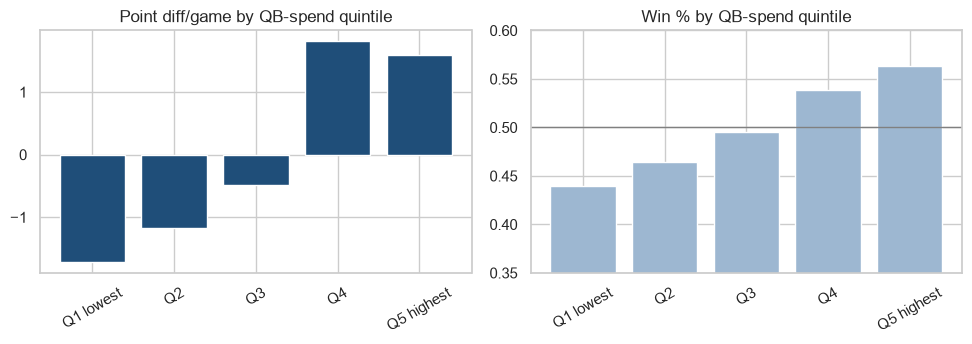

,avg_qb_starter_cap_m,qb_share_pct,win_pct,pt_diff_pg,n
qb_quintile,,,,,
Q1 lowest,1.576,1.005,0.440,-1.713,84
Q2,5.350,3.313,0.464,-1.176,83
Q3,9.290,5.766,0.495,-0.484,83
Q4,18.876,11.447,0.538,1.807,83
Q5 highest,26.326,16.506,0.564,1.598,83


In [6]:
ts["qb_quintile"] = pd.qcut(ts.QB_starter_share, 5, labels=["Q1 lowest", "Q2", "Q3", "Q4", "Q5 highest"])
q = ts.groupby("qb_quintile", observed=True).agg(avg_qb_starter_cap_m=("QB_starter", "mean"), qb_share_pct=("QB_st", "mean"),
        win_pct=("win_pct", "mean"), pt_diff_pg=("pt_diff_pg", "mean"), n=("team", "size"))
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].bar(q.index, q.pt_diff_pg, color="#1f4e79"); ax[0].set(title="Point diff/game by QB-spend quintile")
ax[1].bar(q.index, q.win_pct, color="#9db7d1"); ax[1].axhline(.5, color="grey", lw=1); ax[1].set(title="Win % by QB-spend quintile", ylim=(.35, .6))
for a in ax: a.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show(); q.round(3)

In [7]:
# is it dollars at QB or just "good teams pay QBs"? try lagged spending (last year's QB share -> this year's results)
ts = ts.sort_values(["team", "season"])
ts["QB_st_lag"] = ts.groupby("team")["QB_st"].shift(1)
lag = fit("pt_diff_pg ~ QB_st_lag", ts.dropna(subset=["QB_st_lag"]))
same = fit("pt_diff_pg ~ QB_st")
print(f"same-season QB starter share: {same.params['QB_st']:.3f} pts/g per pt (p={same.pvalues['QB_st']:.3g})")
print(f"prior-season QB starter share: {lag.params['QB_st_lag']:.3f} pts/g per pt (p={lag.pvalues['QB_st_lag']:.3g})")

# the cheap-QB exception: rookie-deal QBs who played a lot
starters = ps[(ps.pos_group == "QB") & (ps.role == "starter")]
print("\nStarting QBs by cap hit tier (cap $M):")
print(starters.groupby(pd.cut(starters.cap_m, [0, 5, 15, 30, 100])).size())

same-season QB starter share: 0.234 pts/g per pt (p=3.55e-05)
prior-season QB starter share: 0.134 pts/g per pt (p=0.0242)

Starting QBs by cap hit tier (cap $M):
cap_m
(0, 5]       128
(5, 15]      138
(15, 30]     126
(30, 100]     24
dtype: int64


### 4b. Controlling for rookie-contract QBs

**The concern:** QBs on cheap rookie-scale deals are a big group (183 of 416 team-seasons, 44%; median cap hit about $6M vs about $17M for veterans). If rookie-deal QBs happen to be bad, the QB-spend relationship could just be \"cheap QB = young QB = worse\" rather than anything about money.

**Result: it is not.** Adding a rookie-deal flag leaves the QB spend coefficient essentially unchanged (0.234 → 0.240), adding the QB's draft pick as well moves it to 0.257, and the flag itself is about zero (+0.12 pts/game, p=0.87) with no interaction. The slope is about the same within veteran-deal QB1s (0.253, p<0.001) and within rookie-deal QB1s (0.256, though that estimate is noisier, p=0.085). In the all-position model, QB's coefficient goes from 0.307 to 0.299.

So **rookie QBs are not worse on average once you account for how much the team spends on the QB position**: the spending relationship holds *within* both groups.

**A new pattern among veteran-deal QBs:** point differential rises from the cheapest quartile (-2.1, about $4M, often stopgap starters) through the third quartile (+2.9, about $20M), then **drops to +0.8 in the top quartile (about $29M)**. That gap of about 2 pts/game is only about 2 standard errors with 58 team-seasons per bar, so it is suggestive of diminishing returns at the very top, not established.

*Limits:* the flag is date-based, so it misclassifies a few early extensions (for example, Burrow's 2023 season counts as rookie-scale because he is within 4 years of the draft, though he was already extended). Players on rookie deals who are great and players who are bad are both in the \"rookie\" group, so this separates contract type from QB spend, not QB talent from QB spend.

In [8]:
# rookie-scale = drafted QB within 4 seasons of the draft (5 for 1st-rounders). Defined in src/build_data.py.
ts["rookie"] = ts.qb1_rookie_deal.astype(int)
ts["qb1_pick"] = ts.qb1_draft_overall.fillna(260)   # undrafted = after the last pick
print(ts.groupby("rookie").agg(team_seasons=("team", "size"), qb1_cap_m=("qb1_cap_m", "mean"), qb_share_pct=("QB_st", "mean"),
      pt_diff_pg=("pt_diff_pg", "mean"), win_pct=("win_pct", "mean")).round(2), "\n")

def row(label, m, d):
    return {"model": label, "QB_st coef": m.params["QB_st"], "se": m.bse["QB_st"], "p": m.pvalues["QB_st"], "n": int(m.nobs)}
vet, rk = ts[ts.rookie == 0], ts[ts.rookie == 1]
m1, m2 = fit("pt_diff_pg ~ QB_st"), fit("pt_diff_pg ~ QB_st + rookie")
m2b = fit("pt_diff_pg ~ QB_st + rookie + np.log(qb1_pick)")
m3 = fit("pt_diff_pg ~ QB_st * rookie")
tab = pd.DataFrame([row("1. baseline (no control)", m1, ts), row("2. + rookie-deal flag", m2, ts),
                    row("3. + flag + log(QB1 draft pick)", m2b, ts),
                    row("4. veteran-deal QB1 only", fit("pt_diff_pg ~ QB_st", vet), vet),
                    row("5. rookie-deal QB1 only", fit("pt_diff_pg ~ QB_st", rk), rk)]).set_index("model")
print(f"rookie flag coefficient (model 2): {m2.params['rookie']:.2f} pts/g (p={m2.pvalues['rookie']:.2f}); "
      f"QB_st x rookie interaction (model 3 spec): {m3.params['QB_st:rookie']:.3f} (p={m3.pvalues['QB_st:rookie']:.2f})")
tab.round(3)

        team_seasons  qb1_cap_m  qb_share_pct  pt_diff_pg  win_pct
rookie                                                            
0                233     16.920        10.530       0.640    0.520
1                183      6.320         3.850      -0.810    0.480 

rookie flag coefficient (model 2): 0.12 pts/g (p=0.87); QB_st x rookie interaction (model 3 spec): 0.016 (p=0.91)


,QB_st coef,se,p,n
model,,,,
1. baseline (no control),0.234,0.057,0.000,416
2. + rookie-deal flag,0.240,0.062,0.000,416
3. + flag + log(QB1 draft pick),0.257,0.076,0.001,416
4. veteran-deal QB1 only,0.253,0.063,0.000,233
5. rookie-deal QB1 only,0.256,0.149,0.085,183


QB starter coef: 0.307 -> 0.299 with rookie control (p=3.21e-06); rookie flag: -0.17 (p=0.83)


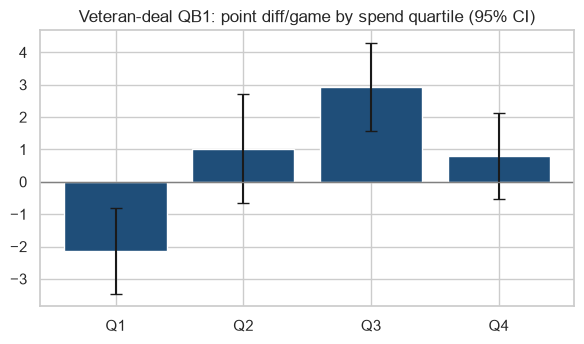

,n,qb1_cap_m,pt_diff_pg,win_pct,se
tier,,,,,
Q1,59,3.810,-2.130,0.420,0.680
Q2,58,15.040,1.020,0.520,0.860
Q3,58,20.270,2.940,0.590,0.690
Q4,58,28.770,0.790,0.540,0.680


In [9]:
# same joint model as section 2, now with the rookie flag: does QB's standing change?
mj = fit("pt_diff_pg ~ " + " + ".join(f"{p}_st" for p in POS) + " + ST_pct + rookie")
print(f"QB starter coef: {m_joint.params['QB_st']:.3f} -> {mj.params['QB_st']:.3f} with rookie control (p={mj.pvalues['QB_st']:.3g}); "
      f"rookie flag: {mj.params['rookie']:.2f} (p={mj.pvalues['rookie']:.2f})")

# among veteran-deal QBs only: is more always better?
v = vet.copy(); v["tier"] = pd.qcut(v.QB_starter_share, 4, labels=["Q1", "Q2", "Q3", "Q4"])
vt = v.groupby("tier", observed=True).agg(n=("team", "size"), qb1_cap_m=("qb1_cap_m", "mean"), pt_diff_pg=("pt_diff_pg", "mean"),
        sd=("pt_diff_pg", "std"), win_pct=("win_pct", "mean"))
vt["se"] = vt.sd / np.sqrt(vt.n)
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.bar(vt.index, vt.pt_diff_pg, yerr=1.96 * vt.se, capsize=4, color="#1f4e79")
ax.axhline(0, color="grey", lw=1); ax.set(title="Veteran-deal QB1: point diff/game by spend quartile (95% CI)")
plt.tight_layout(); plt.show(); vt.drop(columns="sd").round(2)

## 5. Deep dive: Wide receiver

WR spend does **not** show the QB pattern. The lowest-spending quintile (about 2.7% of cap) is worst (−1.4 pts/game), but from Q2 upward it is flat: roughly 0 to +0.8 with no trend, and the top quintile (about 14%) is at about 0. That looks like **diminishing returns after a modest level of WR investment**, not a payoff for stars.

Splitting WR spend into the top-paid WR vs. the other starters, neither is distinguishable from zero (top WR +0.04, others −0.03 per point of cap share, wide intervals). Bench WR spend is negative but not significant (−0.20, p=0.11). With 416 team-seasons, we can rule out large WR effects but not small ones.

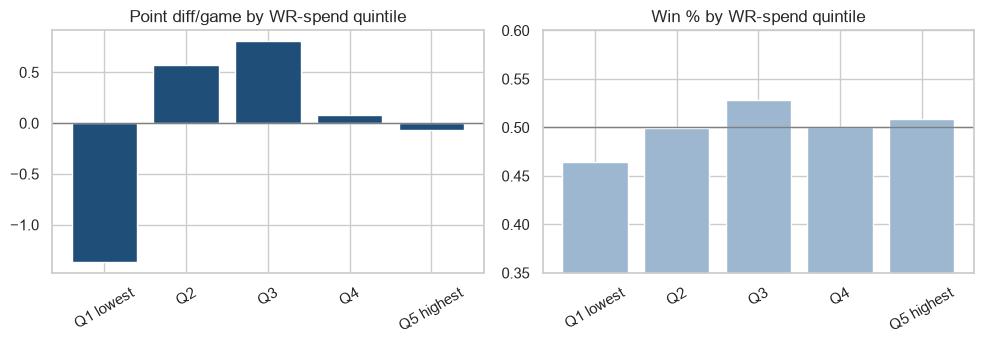

,wr_share_pct,win_pct,pt_diff_pg,n
wr_quintile,,,,
Q1 lowest,2.660,0.465,-1.365,84
Q2,4.979,0.499,0.574,83
Q3,7.218,0.528,0.803,83
Q4,10.015,0.501,0.083,83
Q5 highest,14.341,0.508,-0.067,83


In [10]:
ts["wr_quintile"] = pd.qcut(ts.WR_starter_share, 5, labels=["Q1 lowest", "Q2", "Q3", "Q4", "Q5 highest"])
w = ts.groupby("wr_quintile", observed=True).agg(wr_share_pct=("WR_st", "mean"), win_pct=("win_pct", "mean"),
        pt_diff_pg=("pt_diff_pg", "mean"), n=("team", "size"))
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].bar(w.index, w.pt_diff_pg, color="#1f4e79"); ax[0].axhline(0, color="grey", lw=1); ax[0].set(title="Point diff/game by WR-spend quintile")
ax[1].bar(w.index, w.win_pct, color="#9db7d1"); ax[1].axhline(.5, color="grey", lw=1); ax[1].set(title="Win % by WR-spend quintile", ylim=(.35, .6))
for a in ax: a.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show(); w.round(3)

In [11]:
# does it matter HOW the WR money is split? top-paid WR vs. the other starting WRs
wr = ps[(ps.pos_group == "WR") & (ps.role == "starter")].copy()
wr["cap_rank"] = wr.groupby(["season", "team"])["cap_m"].rank(ascending=False, method="first")
wr["slot"] = np.where(wr.cap_rank == 1, "WR_top", "WR_other")
split = wr.pivot_table(index=["season", "team"], columns="slot", values="cap_m", aggfunc="sum", fill_value=0).reset_index()
d = ts.merge(split, on=["season", "team"])
d["WR_top_pct"] = d.WR_top / d.tracked_cap_m * 100; d["WR_other_pct"] = d.WR_other / d.tracked_cap_m * 100
m = fit("pt_diff_pg ~ WR_top_pct + WR_other_pct + WR_bn", d)
pd.DataFrame({"coef": m.params, "p": m.pvalues, "lo": m.conf_int()[0], "hi": m.conf_int()[1]}).loc[["WR_top_pct", "WR_other_pct", "WR_bn"]].round(3)

,coef,p,lo,hi
WR_top_pct,0.041,0.715,-0.180,0.263
WR_other_pct,-0.031,0.884,-0.444,0.383
WR_bn,-0.198,0.111,-0.441,0.045


## 6. Robustness

- **Win % as outcome (a):** same story. QB (p=0.005) and TE (p=0.03) are the only positions with significant starter coefficients.
- **Last season's spending (b):** QB (+0.12, p=0.046) and TE (+0.39, p=0.009) survive; everything else stays near zero. Using lagged spending reduces, but does not eliminate, the "good teams just spend more" concern.

In [12]:
# (a) win % as the outcome instead of point differential
rows = []
for p in POS:
    a = fit(f"win_pct ~ {p}_st + {p}_bn")
    rows.append({"pos": p, "starter_coef_winpct": a.params[f"{p}_st"], "p": a.pvalues[f"{p}_st"]})
pd.DataFrame(rows).set_index("pos").round(4)

,starter_coef_winpct,p
pos,,
QB,0.005,0.005
RB,0.002,0.755
WR,0.001,0.602
TE,0.011,0.030
OL,-0.000,0.965
DL,-0.001,0.646
EDGE,0.002,0.411
LB,-0.000,0.940
CB,-0.001,0.812


In [13]:
# (b) all positions with last season's spending (reduces "good teams spend more" reverse causality)
lagcols = []
for p in POS:
    ts[f"{p}_st_lag"] = ts.groupby("team")[f"{p}_st"].shift(1); lagcols.append(f"{p}_st_lag")
ts["ST_lag"] = ts.groupby("team")["ST_pct"].shift(1)
m_lag = fit("pt_diff_pg ~ " + " + ".join(lagcols) + " + ST_lag", ts.dropna(subset=lagcols))
pd.DataFrame({"coef": m_lag.params, "p": m_lag.pvalues}).loc[lagcols].round(3)

,coef,p
QB_st_lag,0.118,0.046
RB_st_lag,-0.117,0.508
WR_st_lag,-0.015,0.815
TE_st_lag,0.390,0.009
OL_st_lag,0.060,0.435
DL_st_lag,-0.069,0.361
EDGE_st_lag,0.035,0.729
LB_st_lag,-0.039,0.674
CB_st_lag,-0.078,0.482
S_st_lag,-0.006,0.964


## 7. EPA/play: offense vs. defense

Point differential blends offense, defense, and special teams. EPA/play lets us test something sharper: **spending on offensive starters should show up in offensive EPA, and defensive starters in defensive EPA.** Units are EPA per 100 plays, with defense flipped so higher is better for both. Same model as section 2 (bench spending is the baseline).

**What lines up with how football works**
- **QB:** +0.53 offensive EPA per point of cap share (p<0.001), and it is all passing (+0.57 pass vs. +0.02 rush in the position-level models). It does nothing for defense (p=0.40). The rookie-deal control leaves it unchanged (pass EPA 0.711 → 0.703).
- **OL:** +0.34 offensive EPA (p=0.002). In the pass/rush split the gain is in the **run game** (+0.20, p=0.04), not pass blocking (+0.04).
- **EDGE and CB** help the defense (+0.24 and +0.34, both p<0.001), through **pass defense** (EDGE +0.36, CB +0.42 on pass EPA allowed, both p≤0.002).
- **Interior DL** helps the defense (+0.18, p=0.04), through **run defense** (+0.26, p=0.001).
- **S and LB:** no clear effect (LB run defense +0.18, p=0.10).

**Placebo test: it flags TE.** Offensive spending should not move defense and vice versa. Defensive starters never predict offense (all p>0.39), and QB/RB/WR/OL never predict defense (all p>0.4). **TE is the exception: TE spend predicts *defensive* EPA (+0.42, p=0.007) about as strongly as offensive (+0.50, p=0.06).** A tight end cannot cause that, so the TE result in sections 2, 3 and 6 is most likely noise or a proxy for something else, such as a few well-run teams. I'm downgrading it.

**WR is the main revision to earlier conclusions.** On point differential, WR spend looked flat (section 5). On offensive EPA it shows a modest but real effect (+0.29, p=0.002 in the joint model; +0.30 on pass EPA, p=0.056). Point differential was too blunt to detect it. Read section 5's \"no payoff\" as \"no *large* payoff\".

**A caution:** this section tests 10 positions across several outcomes, so a few p<0.05 results are expected by chance, and the pass/rush splits are exploratory. What gives confidence is the *pattern*: effects land on the right side of the ball and the right phase of the game, and the placebo test holds for every position except TE.

In [14]:
# EPA per 100 plays; defense is flipped so that HIGHER = BETTER for both sides
ts["off"] = ts.off_epa_play * 100
ts["off_pass"], ts["off_rush"] = ts.off_pass_epa_play * 100, ts.off_rush_epa_play * 100
ts["dfn"] = -ts.def_epa_play * 100
ts["dfn_pass"], ts["dfn_rush"] = -ts.def_pass_epa_play * 100, -ts.def_rush_epa_play * 100
print("corr with point diff/game:", ts[["off", "dfn"]].corrwith(ts.pt_diff_pg).round(2).to_dict())

rhs = " + ".join(f"{p}_st" for p in POS) + " + ST_pct"      # same spec as section 2 (bench = reference)
joint = {name: fit(f"{y} ~ {rhs}") for name, y in [("point diff", "pt_diff_pg"), ("offense EPA", "off"), ("defense EPA", "dfn")]}
cols = [f"{p}_st" for p in POS]
tab = pd.concat({k: pd.DataFrame({"coef": m.params[cols], "p": m.pvalues[cols]}) for k, m in joint.items()}, axis=1)
tab.index = POS
tab.round(3)

corr with point diff/game: {'off': 0.78, 'dfn': 0.62}


point diff       offense EPA       defense EPA      
           coef     p        coef     p        coef     p
QB        0.307 0.000       0.525 0.000       0.045 0.401
RB        0.219 0.167       0.283 0.133       0.114 0.546
WR        0.128 0.063       0.294 0.002      -0.029 0.721
TE        0.442 0.006       0.503 0.063       0.422 0.007
OL        0.152 0.026       0.337 0.002      -0.006 0.929
DL        0.098 0.199       0.060 0.565       0.180 0.037
EDGE      0.193 0.027       0.140 0.396       0.241 0.000
LB        0.133 0.243       0.036 0.793       0.166 0.221
CB        0.173 0.024      -0.018 0.881       0.341 0.000
S         0.092 0.533       0.092 0.633       0.113 0.432

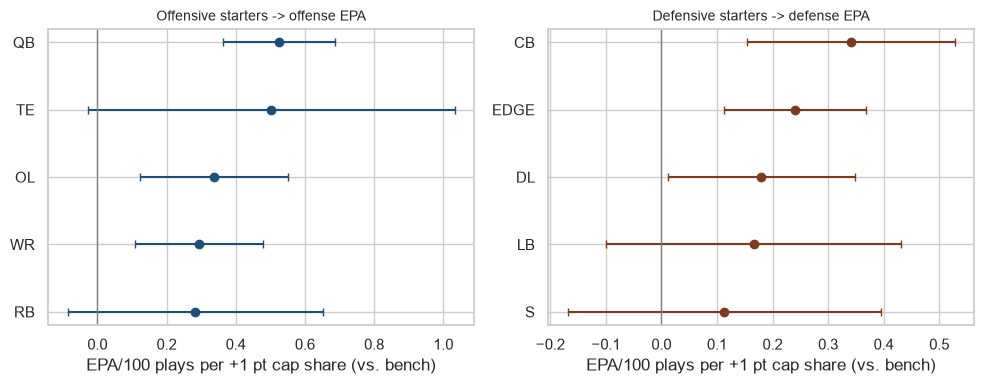

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
off_pos, def_pos = ["QB", "RB", "WR", "TE", "OL"], ["DL", "EDGE", "LB", "CB", "S"]
for ax, key, plist, color, title in [(axes[0], "offense EPA", off_pos, "#1f4e79", "Offensive starters -> offense EPA"),
                                     (axes[1], "defense EPA", def_pos, "#7a3b1f", "Defensive starters -> defense EPA")]:
    m = joint[key]; ci = m.conf_int().loc[[f"{p}_st" for p in plist]]; c = m.params[[f"{p}_st" for p in plist]]
    order = c.sort_values().index
    ax.errorbar(c[order], range(len(order)), xerr=[c[order] - ci.loc[order, 0], ci.loc[order, 1] - c[order]], fmt="o", color=color, capsize=3)
    ax.axvline(0, color="grey", lw=1); ax.set_yticks(range(len(order))); ax.set_yticklabels([o.replace("_st", "") for o in order]); ax.set_title(title, fontsize=10)
    ax.set_xlabel("EPA/100 plays per +1 pt cap share (vs. bench)")
plt.tight_layout(); plt.show()

In [16]:
# mechanism check: split each side into pass and rush EPA, and show starter vs bench spend for the relevant positions
rows = []
for p in off_pos:
    for y, lab in [("off_pass", "off pass EPA"), ("off_rush", "off rush EPA")]:
        m = fit(f"{y} ~ {p}_st + {p}_bn"); rows.append({"pos": p, "outcome": lab, "starter_coef": m.params[f"{p}_st"], "starter_p": m.pvalues[f"{p}_st"], "bench_coef": m.params[f"{p}_bn"], "bench_p": m.pvalues[f"{p}_bn"]})
for p in def_pos:
    for y, lab in [("dfn_pass", "def pass EPA"), ("dfn_rush", "def rush EPA")]:
        m = fit(f"{y} ~ {p}_st + {p}_bn"); rows.append({"pos": p, "outcome": lab, "starter_coef": m.params[f"{p}_st"], "starter_p": m.pvalues[f"{p}_st"], "bench_coef": m.params[f"{p}_bn"], "bench_p": m.pvalues[f"{p}_bn"]})
mech = pd.DataFrame(rows).set_index(["pos", "outcome"]); mech.round(3)

starter_coef  starter_p  bench_coef  bench_p
pos  outcome                                                   
QB   off pass EPA         0.573      0.000      -0.467    0.001
     off rush EPA         0.015      0.845      -0.238    0.000
RB   off pass EPA        -0.079      0.800      -0.569    0.035
     off rush EPA         0.334      0.062       0.046    0.760
WR   off pass EPA         0.295      0.056      -0.117    0.633
     off rush EPA        -0.027      0.815      -0.050    0.712
TE   off pass EPA         0.529      0.217      -0.276    0.435
     off rush EPA         0.399      0.044       0.009    0.958
OL   off pass EPA         0.039      0.811      -0.655    0.002
     off rush EPA         0.195      0.038      -0.259    0.025
DL   def pass EPA         0.070      0.642       0.087    0.626
     def rush EPA         0.256      0.001      -0.067    0.575
EDGE def pass EPA         0.355      0.002       0.181    0.206
     def rush EPA         0.005      0.953      -0.139    0.171
LB   def pass EPA        -0.056      0.789      -0.317    0.124
     def rush EPA         0.183      0.097      -0.165    0.354
CB   def pass EPA         0.424      0.001      -0.146    0.276
     def rush EPA         0.055      0.632      -0.002    0.987
S    def pass EPA         0.017      0.947      -0.026    0.930
     def rush EPA        -0.082      0.457       0.012    0.956

In [17]:
# QB check: does the rookie-contract control still leave a QB -> offense effect?
for y in ["off", "off_pass"]:
    a, b = fit(f"{y} ~ QB_st"), fit(f"{y} ~ QB_st + rookie")
    print(f"{y:9s}: QB_st {a.params['QB_st']:.3f} (p={a.pvalues['QB_st']:.3g}) -> with rookie flag {b.params['QB_st']:.3f} (p={b.pvalues['QB_st']:.3g})")

off      : QB_st 0.461 (p=3.01e-08) -> with rookie flag 0.492 (p=5.01e-08)
off_pass : QB_st 0.711 (p=1.32e-09) -> with rookie flag 0.703 (p=3.54e-07)


## 8. Sensitivity to the starter definition

Everything so far uses one definition of \"starter\" (top-N by snaps, filling a base 11-man lineup). Here I rerun the key findings under five alternatives: a *narrower* lineup (WR2, CB2, LB1), a *wider* one (RB2, WR4, TE2, OL6, DL3, EDGE3, LB3, CB4, S3), and snap-share cutoffs of 33%, 50% and 66%. Definitions change the *scale* of each position's starter share, so the heatmap shows the effect of a one-standard-deviation shift, which is comparable across definitions. This is a robustness check on my own choices, not independent evidence, since it is the same data each time.

**What holds under every definition**
- **QB**: significant for both point differential and offensive EPA in all six (about +1.7 to +2.1 pts/game and +2.6 to +3.3 EPA/100 plays per 1 SD).
- **WR, OL → offense** and **EDGE, CB → defense**: significant in all six.
- **Non-starting QB and OL money is negative** in all six (all p≤0.001), so that finding does not depend on where the starter line is drawn.

**What is fragile**
- **Interior DL → defense** is significant in only 4 of 6 (not under the narrow lineup or the 66% cutoff). Treat it as the weakest of the defensive findings.
- **TE → offense** is significant in only 2 of 6 (the 50% and 66% cutoffs), so it never held up reliably. Meanwhile the **TE → defense placebo "effect" shows up in 5 of 6**, which reinforces treating TE as noise rather than a real effect.

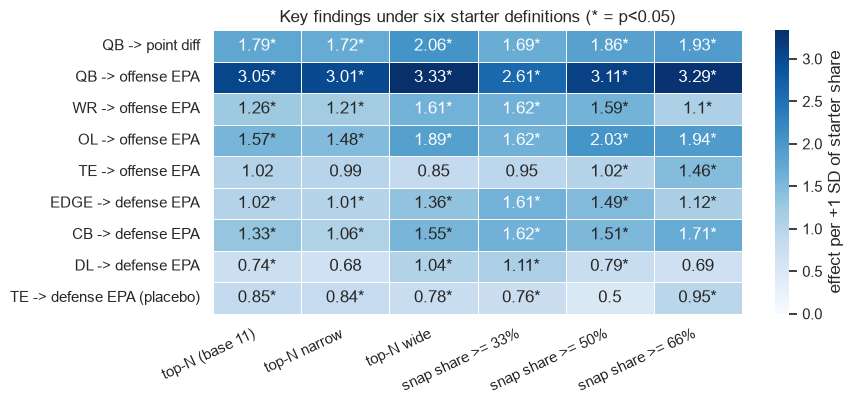

avg starters per team-season: {'top-N (base 11)': np.float64(22.0), 'top-N narrow': np.float64(19.0), 'top-N wide': np.float64(30.9), 'snap share >= 33%': np.float64(27.4), 'snap share >= 50%': np.float64(19.5), 'snap share >= 66%': np.float64(13.3)}


,QB bench coef,QB bench p,OL bench coef,OL bench p
top-N (base 11),-0.295,0.000,-0.330,0.001
top-N narrow,-0.295,0.000,-0.330,0.001
top-N wide,-0.295,0.000,-0.446,0.000
snap share >= 33%,-0.314,0.000,-0.412,0.000
snap share >= 50%,-0.299,0.000,-0.370,0.000
snap share >= 66%,-0.273,0.000,-0.346,0.000


In [18]:
import sys; sys.path.insert(0, "src")
from build_data import STARTER_RULES, assign_roles, share_table

outcomes = ts[["season", "team", "pt_diff_pg", "off", "dfn"]]
FINDINGS = [("QB -> point diff", "pt_diff_pg", "QB_st"), ("QB -> offense EPA", "off", "QB_st"), ("WR -> offense EPA", "off", "WR_st"),
            ("OL -> offense EPA", "off", "OL_st"), ("TE -> offense EPA", "off", "TE_st"), ("EDGE -> defense EPA", "dfn", "EDGE_st"),
            ("CB -> defense EPA", "dfn", "CB_st"), ("DL -> defense EPA", "dfn", "DL_st"), ("TE -> defense EPA (placebo)", "dfn", "TE_st")]
JOINT_RHS = " + ".join(f"{p}_st" for p in POS) + " + ST_pct"

def rebuild(rule):
    p = ps.copy(); p["role"] = assign_roles(p, rule)
    d = share_table(p).merge(outcomes, on=["season", "team"])
    for q in POS:
        d[f"{q}_st"], d[f"{q}_bn"] = d[f"{q}_starter_share"] * 100, d[f"{q}_bench_share"] * 100
    d["ST_pct"] = d.ST_all_share * 100
    return d, p[p.role == "starter"].groupby(["season", "team"]).size().mean()

effect, stars, bench, nstart = {}, {}, {}, {}
for name, rule in STARTER_RULES.items():
    d, nstart[name] = rebuild(rule)
    joint_fits = {y: fit(f"{y} ~ {JOINT_RHS}", d) for y in ["pt_diff_pg", "off", "dfn"]}
    effect[name], stars[name] = {}, {}
    for label, y, v in FINDINGS:
        m = joint_fits[y]
        effect[name][label] = m.params[v] * d[v].std()          # pts or EPA/100 per +1 SD of that position's starter share
        stars[name][label] = "*" if m.pvalues[v] < 0.05 else ""
    qb, ol = fit("pt_diff_pg ~ QB_st + QB_bn", d), fit("pt_diff_pg ~ OL_st + OL_bn", d)
    bench[name] = {"QB bench coef": qb.params["QB_bn"], "QB bench p": qb.pvalues["QB_bn"],
                   "OL bench coef": ol.params["OL_bn"], "OL bench p": ol.pvalues["OL_bn"]}

E, S = pd.DataFrame(effect), pd.DataFrame(stars)
fig, ax = plt.subplots(figsize=(9, 4.2))
sns.heatmap(E, annot=E.round(2).astype(str) + S, fmt="", cmap="Blues", vmin=0, cbar_kws={"label": "effect per +1 SD of starter share"}, ax=ax, linewidths=.5)
ax.set(title="Key findings under six starter definitions (* = p<0.05)", xlabel="", ylabel="")
plt.xticks(rotation=25, ha="right"); plt.tight_layout(); plt.show()
print("avg starters per team-season:", {k: round(v, 1) for k, v in nstart.items()})
pd.DataFrame(bench).T.round(3)

## 9. Why is non-starter QB and OL money so negative?

Section 3 found that cap tied up in non-starting QBs and OL goes with *worse* results. That could mean (1) **injuries** (the expensive starter got hurt, so his cap hit becomes \"bench\" money), (2) **selection** (bad teams just look different), or (3) **real waste** (overpaid depth). To separate them I split every non-starter's cap by *why* he isn't a starter, using weekly roster status and snaps. This section uses 2016+ only, because injured-reserve weeks look undercounted in 2013-15 (about 0.9 per player vs. 1.7+ afterwards).

**1. Injured-reserve money is the main driver for both positions, and it is mechanical.**
A 1-SD higher IR cap share costs about 1.2 pts/game in the same season (QB −1.20, OL −1.24, both p<0.001). But *last* season's IR money does not predict this season (QB +0.09, p=0.85; OL −0.26, p=0.57). That is the signature of an injury effect: the star got hurt and the team suffered *that year*. It is not evidence of bad roster decisions. The same pattern shows up for backup QBs who actually played (−0.62 same-season, −0.12 prior-season): a backup played because the starter was out.

**2. Healthy OL who never play also look bad, but mostly as a proxy for team quality.**
This group (no snaps, not on IR, not cut) is small money (about $0.8M per player), yet it has a large same-season effect (−1.28 per SD, p<0.001) that *does* carry into the next season (−0.87, p=0.004). That persistence looks like roster-building rather than injury. However, controlling for last season's point differential cuts it from −0.65 to −0.27 and it is no longer significant (p=0.34), so it mostly reflects bad teams staying bad. Early-round rookie linemen who sit are a tiny group (16 player-seasons, 17% of this money, about $3.2M each). Their effect is bigger and survives the control (−1.10, p=0.03), but 16 observations is too few to lean on.

**3. Cut and practice-squad money** (the closest thing to dead cap we can see) is negligible for both positions.

**Bottom line:** the \"wasted bench money\" reading of section 3 is mostly wrong. The signal is largely **injuries**, plus a **team-quality proxy**. It does not show that expensive depth is waste, and it does not show that depth is worth paying for either. What it does show is the *cost of injury exposure* at QB and OL.

*Caveats:* the 4-week IR cutoff is a judgment call, roster-status coding may be imperfect, \"idle\" can include players who were hurt but never placed on IR, and all of this is observational.

In [19]:
# split every non-starter's cap into WHY he isn't a starter, using weekly roster status and snaps:
#   ir          = 4+ regular-season weeks on injured reserve / PUP / NWT
#   played      = not a top-N starter but took snaps
#   idle_roster = no snaps, mostly on the active/inactive roster (healthy scratch, developmental)
#   idle_cut    = no snaps, mostly off the active roster (cut / practice squad)
# IR weeks look undercounted in 2013-15 (check below), so this section uses 2016+.
print("avg IR weeks per player-season:", ps.groupby("season").weeks_ir.mean().round(2).to_dict())
off_roster = ps.weeks_other > (ps.weeks_act + ps.weeks_ina)
ps["cat"] = np.select([ps.role == "starter", ps.weeks_ir >= 4, ps.unit_snaps > 0, off_roster],
                      ["starter", "ir", "played", "idle_cut"], "idle_roster")
CATS = ["starter", "ir", "played", "idle_roster", "idle_cut"]

def cat_shares(pos):
    t = ps[ps.pos_group == pos].pivot_table(index=["season", "team"], columns="cat", values="cap_m", aggfunc="sum", fill_value=0)
    t = t.reindex(columns=CATS, fill_value=0).div(ts.set_index(["season", "team"]).tracked_cap_m, axis=0) * 100
    t.columns = [f"c_{pos}_{c}" for c in CATS]
    return t.reset_index()

for pos in ["QB", "OL"]:
    ts = ts.merge(cat_shares(pos), on=["season", "team"], how="left")
ts = ts.sort_values(["team", "season"])
d16 = ts[ts.season >= 2016]

summary = (ps[ps.pos_group.isin(["QB", "OL"]) & (ps.season >= 2016)].groupby(["pos_group", "cat"])
           .agg(player_seasons=("cap_m", "size"), avg_cap_m=("cap_m", "mean"), total_cap_m=("cap_m", "sum")).round(2))
summary

avg IR weeks per player-season: {2013: 0.88, 2014: 0.92, 2015: 1.02, 2016: 1.63, 2017: 1.76, 2018: 1.7, 2019: 1.77, 2020: 1.76, 2021: 2.09, 2022: 1.77, 2023: 1.68, 2024: 1.9, 2025: 2.02}


player_seasons  avg_cap_m  total_cap_m
pos_group cat                                                
OL        idle_cut                692      0.130       93.310
          idle_roster             358      0.820      294.050
          ir                      621      2.420     1500.860
          played                 1167      1.090     1269.950
          starter                1600      4.620     7395.420
QB        idle_cut                163      0.140       23.620
          idle_roster             134      0.850      113.870
          ir                       98      6.810      667.660
          played                  417      2.260      941.190
          starter                 320     13.410     4291.590

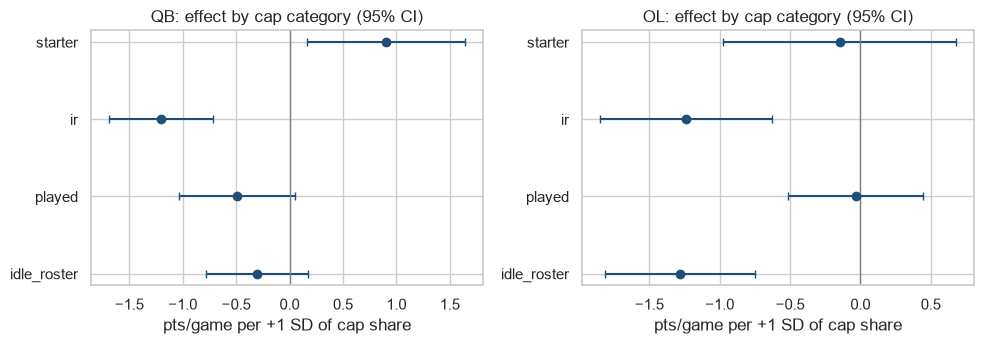

QB                                OL                \
            effect_per_sd     lo     hi     p effect_per_sd     lo     hi   
starter             0.902  0.159  1.644 0.017        -0.147 -0.974  0.681   
ir                 -1.203 -1.690 -0.715 0.000        -1.239 -1.850 -0.628   
played             -0.492 -1.038  0.053 0.077        -0.034 -0.513  0.446   
idle_roster        -0.306 -0.783  0.171 0.208        -1.283 -1.816 -0.749   
idle_cut           -0.234 -0.964  0.496 0.530         0.036 -0.288  0.360   

                   
                p  
starter     0.728  
ir          0.000  
played      0.891  
idle_roster 0.000  
idle_cut    0.829

In [20]:
# same-season effects, 2016+: effect on point diff/game of a 1-SD higher cap share in each category
def effects(pos, data, lagged=False):
    suffix = "_lag" if lagged else ""
    cs = [f"c_{pos}_{c}{suffix}" for c in CATS]
    m = fit("pt_diff_pg ~ " + " + ".join(cs), data)
    sd = data[cs].std()
    return pd.DataFrame({"effect_per_sd": m.params[cs] * sd, "lo": (m.params[cs] - 1.96 * m.bse[cs]) * sd,
                         "hi": (m.params[cs] + 1.96 * m.bse[cs]) * sd, "p": m.pvalues[cs]}).set_axis(CATS)

same = {pos: effects(pos, d16) for pos in ["QB", "OL"]}
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, pos in zip(axes, ["QB", "OL"]):
    e = same[pos].drop(index="idle_cut")[::-1]
    ax.errorbar(e.effect_per_sd, range(len(e)), xerr=[e.effect_per_sd - e.lo, e.hi - e.effect_per_sd], fmt="o", color="#1f4e79", capsize=3)
    ax.axvline(0, color="grey", lw=1); ax.set_yticks(range(len(e))); ax.set_yticklabels(e.index)
    ax.set(title=f"{pos}: effect by cap category (95% CI)", xlabel="pts/game per +1 SD of cap share")
plt.tight_layout(); plt.show()
pd.concat(same, axis=1).round(3)

In [21]:
# is it mechanical (this year's injury hurts this year) or persistent (a roster-building flaw)?
# if persistent, LAST season's money in the category should predict THIS season's results too
for pos in ["QB", "OL"]:
    for c in CATS:
        ts[f"c_{pos}_{c}_lag"] = ts.groupby("team")[f"c_{pos}_{c}"].shift(1)
d17 = ts[ts.season >= 2017]
persist = pd.concat({pos: pd.DataFrame({"same_season": effects(pos, d17).effect_per_sd, "same_p": effects(pos, d17).p,
                                        "prior_season": effects(pos, d17, lagged=True).effect_per_sd, "prior_p": effects(pos, d17, lagged=True).p})
                     for pos in ["QB", "OL"]}, axis=1)
persist.round(3)

QB                                      OL         \
            same_season same_p prior_season prior_p same_season same_p   
starter           0.870  0.023        0.572   0.136      -0.154  0.737   
ir               -1.185  0.000        0.093   0.848      -1.316  0.000   
played           -0.617  0.031       -0.118   0.707      -0.003  0.991   
idle_roster      -0.221  0.493       -0.318   0.246      -1.056  0.001   
idle_cut         -0.233  0.547        0.021   0.960       0.022  0.892   

                                  
            prior_season prior_p  
starter            0.365   0.469  
ir                -0.259   0.571  
played            -0.438   0.258  
idle_roster       -0.869   0.004  
idle_cut           0.292   0.163

In [22]:
# OL "idle" money: selection check. (a) is it just high-drafted rookies on bad teams? (b) does it survive controlling for last year's record?
ps["cat2"] = np.where((ps.cat == "idle_roster") & (ps.pos_group == "OL") & ps.rookie_deal & (ps.draft_round <= 2), "idle_early", ps.cat)
idle = ps[(ps.pos_group == "OL") & (ps.season >= 2016) & ps.cat.eq("idle_roster")]
early = idle.rookie_deal & (idle.draft_round <= 2)
print(f"idle-roster OL: {len(idle)} player-seasons, ${idle.cap_m.sum():.0f}M; rookie-deal rounds 1-2 are {early.sum()} of them "
      f"({idle[early].cap_m.sum() / idle.cap_m.sum():.0%} of the money, avg ${idle[early].cap_m.mean():.1f}M vs ${idle[~early].cap_m.mean():.1f}M for the rest)")

t = ps[ps.pos_group == "OL"].pivot_table(index=["season", "team"], columns="cat2", values="cap_m", aggfunc="sum", fill_value=0)
t = t.reindex(columns=CATS + ["idle_early"], fill_value=0).div(ts.set_index(["season", "team"]).tracked_cap_m, axis=0) * 100
t.columns = [f"o_{c}" for c in t.columns]
d = ts.merge(t.reset_index(), on=["season", "team"])
d["prev_pd"] = d.groupby("team").pt_diff_pg.shift(1)
d = d[d.season >= 2017]
cs = ["o_starter", "o_ir", "o_played", "o_idle_roster", "o_idle_early", "o_idle_cut"]
a, b = fit("pt_diff_pg ~ " + " + ".join(cs), d), fit("pt_diff_pg ~ prev_pd + " + " + ".join(cs), d)
sel = pd.DataFrame({"coef (no control)": a.params[cs], "p ": a.pvalues[cs], "coef (+ last season's pt diff)": b.params[cs], "p": b.pvalues[cs]})
print(f"last season's point diff coefficient: {b.params['prev_pd']:.2f} (p={b.pvalues['prev_pd']:.3g}); n={int(b.nobs)}; idle_early is only {int(early.sum())} player-seasons")
sel.round(3)

idle-roster OL: 358 player-seasons, $294M; rookie-deal rounds 1-2 are 16 of them (17% of the money, avg $3.2M vs $0.7M for the rest)
last season's point diff coefficient: 0.39 (p=3.59e-09); n=288; idle_early is only 16 player-seasons


,coef (no control),p,coef (+ last season's pt diff),p
o_starter,-0.041,0.668,0.034,0.659
o_ir,-0.399,0.000,-0.279,0.000
o_played,-0.021,0.895,0.173,0.240
o_idle_roster,-0.645,0.025,-0.269,0.340
o_idle_early,-1.731,0.001,-1.104,0.030
o_idle_cut,0.128,0.818,0.024,0.959


## 10. Caveats & next steps

**Caveats**
- This is association, not causation. Teams choose spending, and strong teams may pay stars *because* they are strong.
- Cap hit is an accounting number (prorated bonuses, restructures), not the market price of a player's production.
- Tracked cap is only part of the official cap (dead money and some players are missing), so I use *shares* of tracked cap. Coverage differs by year.
- Injured-reserve weeks come from weekly roster status and look undercounted before 2016, so section 9 uses 2016+.
- A traded player's cap is assigned to a single team. The starter label uses the team where he played the most snaps.
- 416 team-seasons is a small sample for 10 positions at once, and we test many position/outcome combinations, so a few significant results are expected by chance (see section 7). TE in particular has a small share and a wide interval, and fails the offense/defense placebo test in section 7.
- Starters are defined *after the fact* by snaps. A star who is injured all year counts as bench. That is intended, but it means "bench" includes wasted cap.

**Next steps**
1. The insurance question: when the starting QB goes down, do teams with better (more expensive) backup QBs lose less? Section 9 shows injuries are costly; this asks whether depth money buys protection.
2. Test whether QB returns really flatten above about $25M, with a smoother model.
3. Decide on a dashboard (position explorer by team and season).